In [1]:
import json
from pathlib import Path
base_path = Path('/cluster/raid/home/stea/CWEval/evals_bigdata_reeval')
short_names_models = {
    'CodeLlama-70b-Instruct-hf': 'CodeLlama-70b',
    'deepseek-coder-33b-instruct': 'DeepSeek-33b',
    'Qwen3-Coder-30B-A3B-Instruct': 'Qwen3-30b',
}
# LaTeX-friendly model display names
model_latex_name = {
    'CodeLlama-70b-Instruct-hf': 'CodeLlama-Instruct (70B)',
    'Qwen3-Coder-30B-A3B-Instruct': 'Qwen3-Coder-A3B-Instruct (30B)',
    'deepseek-coder-33b-instruct': 'deepseek-coder-instruct (33B)',
}
models = ['CodeLlama-70b-Instruct-hf', 'Qwen3-Coder-30B-A3B-Instruct', 'deepseek-coder-33b-instruct']
languages = ['c', 'cpp', 'go', 'js', 'py']
category = ['mutated3_prompts_character', 'mutated_prompts_character', 'mutated_token_replacement']
cat_short = {
    'mutated_prompts_character': '1-char',
    'mutated3_prompts_character': '3-char',
    'mutated_token_replacement':  'token',
}


In [2]:
import re

_VARIANT_RE = re.compile(r'v\d+')


def process_results(results: dict, language: str, category: str) -> dict:
    """Parse one res_all.json into {cwe: {mutation_key: {functional, secure, func_insecure}}}.

    Mutation keys are 'original' for the unperturbed prompt, or '{position}_v{variant}'
    for evals_bigdata (6 variants per token/character position).
    """
    processed_results = {}
    for key, values in results.items():
        mutation_token = 'original'
        identifier = key.split('/')[-1]
        if f'_{language}' not in identifier:
            identifier = '_'.join(identifier.split('_')[:3]) + f'_{language}' + '_' + '_'.join(identifier.split('_')[3:])
        assert language in identifier, f"Language {language} not in identifier {identifier}"
        cwe_code = identifier.split(f'_{language}')[0]
        if 'mutated' in identifier:
            mutation_identifier = identifier.split(f'{language}_')[1].split('_test')[0]
            parts = mutation_identifier.split('_')
            has_variant = bool(parts) and _VARIANT_RE.fullmatch(parts[-1]) is not None
            variant = parts[-1] if has_variant else None
            pos_idx = 2 if category == 'mutated_token_replacement' else 1
            position = parts[pos_idx]
            mutation_token = f'{position}_{variant}' if has_variant else position
        if cwe_code not in processed_results:
            processed_results[cwe_code] = {}
        func_insecure = []
        for idx, functional in enumerate(values['functional']):
            func_insecure.append(bool(functional and not values['secure'][idx]))
        values['func_insecure'] = func_insecure
        processed_results[cwe_code][mutation_token] = values
    return processed_results


all_processed_results_by_cat = {}  # {cat: {language: {model: {cwe: ...}}}}
for cat in category:
    all_processed_results_by_cat[cat] = {}
    for language in languages:
        all_processed_results_by_cat[cat][language] = {}
        for model in models:
            name = f'{language}_{cat}_{model}'
            file_path = base_path / name / 'res_all.json'
            with open(file_path, 'r') as f:
                results = json.load(f)
            all_processed_results_by_cat[cat][language][model] = process_results(results, language, cat)


# Baseline Analysis: Original (Non-Mutated) Prompts

Percentage of functional and functional+secure code generations for the original (non-mutated) prompts, per model and language.


In [3]:
import pandas as pd
import numpy as np

baseline_rows = []
for cat, languages_dict in all_processed_results_by_cat.items():
    for language, models_dict in languages_dict.items():
        for model, cwes in models_dict.items():
            for cwe, mutations in cwes.items():
                if 'original' not in mutations:
                    continue
                orig = mutations['original']
                n = len(orig['functional'])
                n_func = sum(orig['functional'])
                n_func_sec = sum(f and s for f, s in zip(orig['functional'], orig['secure']))
                baseline_rows.append({
                    'category': cat, 'language': language, 'model': model, 'cwe': cwe,
                    'n': n, 'n_functional': n_func, 'n_func_secure': n_func_sec,
                })
baseline_df = pd.DataFrame(baseline_rows)

# Average across categories (originals are identical, so this is stable)
baseline_df_avg = baseline_df.groupby(['language', 'model', 'cwe']).agg(
    n=('n', 'mean'),
    n_functional=('n_functional', 'mean'),
    n_func_secure=('n_func_secure', 'mean'),
).reset_index()

agg = baseline_df_avg.groupby(['model', 'language']).agg(
    total=('n', 'sum'),
    functional=('n_functional', 'sum'),
    func_secure=('n_func_secure', 'sum'),
).reset_index()
agg['% functional'] = (100 * agg['functional'] / agg['total']).round(1)
agg['% func+secure'] = (100 * agg['func_secure'] / agg['total']).round(1)

for metric in ['% functional', '% func+secure']:
    print(f"\n{metric} (original prompts):")
    pivot = agg.pivot(index='model', columns='language', values=metric)
    pivot.index = [short_names_models.get(m, m) for m in pivot.index]
    pivot.columns.name = None
    pivot.index.name = None
    display(pivot)

# LaTeX: model rows, lang super-cols each split into func / func-sec
pivot_func = agg.pivot(index='model', columns='language', values='% functional')
pivot_fs   = agg.pivot(index='model', columns='language', values='% func+secure')

def _baseline_latex():
    lines = [
        r"\begin{table*}[t]",
        r"\centering",
        r"\small",
        r"\begin{tabular}{l" + "cc" * len(languages) + "}",
        r"\toprule",
        r"\textbf{Model} & " + " & ".join(
            r"\multicolumn{2}{c}{\textbf{" + l + "}}" for l in languages
        ) + r" \\",
        " ".join([rf"\cmidrule(lr){{{2+2*i}-{3+2*i}}}" for i in range(len(languages))]),
        " & " + " & ".join("func & func-sec" for _ in languages) + r" \\",
        r"\midrule",
    ]
    for m in models:
        cells = [model_latex_name[m]]
        for l in languages:
            cells.append(f"{pivot_func.loc[m, l]:.1f}")
            cells.append(f"{pivot_fs.loc[m, l]:.1f}")
        lines.append(" & ".join(cells) + r" \\")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{Pass rates on the original (non-mutated) prompts of the CWEval benchmark, "
        r"split by programming language. For each model and language we report the percentage "
        r"of generations that are functional (func) and the percentage that are simultaneously "
        r"functional and secure (func-sec).}",
        r"\label{tab:baseline}",
        r"\end{table*}",
    ]
    return "\n".join(lines)

print("\n% --- LaTeX: baseline table ---")
print(_baseline_latex())



% functional (original prompts):


,c,cpp,go,js,py
CodeLlama-70b,15.0,41.3,40.4,49.3,76.0
Qwen3-30b,61.7,71.4,63.2,60.9,88.0
DeepSeek-33b,50.0,54.0,36.8,65.2,82.7



% func+secure (original prompts):


,c,cpp,go,js,py
CodeLlama-70b,10.0,19.0,14.0,26.1,40.0
Qwen3-30b,33.3,52.4,38.6,43.5,56.0
DeepSeek-33b,21.7,22.2,15.8,39.1,38.7



% --- LaTeX: baseline table ---
\begin{table*}[t]
\centering
\small
\begin{tabular}{lcccccccccc}
\toprule
\textbf{Model} & \multicolumn{2}{c}{\textbf{c}} & \multicolumn{2}{c}{\textbf{cpp}} & \multicolumn{2}{c}{\textbf{go}} & \multicolumn{2}{c}{\textbf{js}} & \multicolumn{2}{c}{\textbf{py}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11}
 & func & func-sec & func & func-sec & func & func-sec & func & func-sec & func & func-sec \\
\midrule
CodeLlama-Instruct (70B) & 15.0 & 10.0 & 41.3 & 19.0 & 40.4 & 14.0 & 49.3 & 26.1 & 76.0 & 40.0 \\
Qwen3-Coder-A3B-Instruct (30B) & 61.7 & 33.3 & 71.4 & 52.4 & 63.2 & 38.6 & 60.9 & 43.5 & 88.0 & 56.0 \\
deepseek-coder-instruct (33B) & 50.0 & 21.7 & 54.0 & 22.2 & 36.8 & 15.8 & 65.2 & 39.1 & 82.7 & 38.7 \\
\bottomrule
\end{tabular}
\caption{Pass rates on the original (non-mutated) prompts of the CWEval benchmark, split by programming language. For each model and language we report the percentage of gene

In [4]:
# Number of mutations per CWE, summed across the 3 mutation categories,
# then averaged over CWEs per (model, language).

mutation_counts = []
for cat, languages_dict in all_processed_results_by_cat.items():
    for language, models_dict in languages_dict.items():
        for model, cwes in models_dict.items():
            for cwe, mutations in cwes.items():
                num_mutations = len(mutations) - 1  # exclude original
                mutation_counts.append({
                    'category': cat, 'language': language, 'model': model,
                    'cwe': cwe, 'num_mutations': num_mutations,
                })
mutation_counts_df = pd.DataFrame(mutation_counts)

# Sum across categories within each (model, language, cwe)
per_cwe_total = mutation_counts_df.groupby(['model', 'language', 'cwe']).agg(
    total_mutations=('num_mutations', 'sum')
).reset_index()

avg_total = per_cwe_total.groupby(['model', 'language']).agg(
    avg=('total_mutations', 'mean')
).reset_index()
pivot = avg_total.pivot(index='model', columns='language', values='avg')
pivot.index = [short_names_models.get(m, m) for m in pivot.index]
pivot.columns.name = None
pivot.index.name = None
print('Average number of mutations per CWE (summed across the 3 mutation categories):')
display(pivot.round(1))

# LaTeX
pivot_raw = avg_total.pivot(index='model', columns='language', values='avg')

def _mutations_latex():
    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\small",
        r"\begin{tabular}{l" + "c" * len(languages) + "}",
        r"\toprule",
        r"\textbf{Model} & " + " & ".join(rf"\textbf{{{l}}}" for l in languages) + r" \\",
        r"\midrule",
    ]
    for m in models:
        cells = [model_latex_name[m]] + [f"{pivot_raw.loc[m, l]:.0f}" for l in languages]
        lines.append(" & ".join(cells) + r" \\")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{Average number of prompt mutations generated per CWE, summed across the "
        r"three mutation categories (single-character, three-character, and token replacement). "
        r"Each category contributes six variants per perturbed position, so the count reflects "
        r"the total perturbed-prompt budget per CWE in our experiments.}",
        r"\label{tab:mutations-per-cwe}",
        r"\end{table}",
    ]
    return "\n".join(lines)

print("\n% --- LaTeX: mutations-per-CWE table ---")
print(_mutations_latex())


Average number of mutations per CWE (summed across the 3 mutation categories):


,c,cpp,go,js,py
CodeLlama-70b,2604.6,2616.9,2298.7,2260.2,2110.4
Qwen3-30b,2140.2,2161.7,1913.7,1903.6,1795.7
DeepSeek-33b,2625.3,2636.6,2000.7,2284.4,2128.3



% --- LaTeX: mutations-per-CWE table ---
\begin{table}[t]
\centering
\small
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{c} & \textbf{cpp} & \textbf{go} & \textbf{js} & \textbf{py} \\
\midrule
CodeLlama-Instruct (70B) & 2605 & 2617 & 2299 & 2260 & 2110 \\
Qwen3-Coder-A3B-Instruct (30B) & 2140 & 2162 & 1914 & 1904 & 1796 \\
deepseek-coder-instruct (33B) & 2625 & 2637 & 2001 & 2284 & 2128 \\
\bottomrule
\end{tabular}
\caption{Average number of prompt mutations generated per CWE, summed across the three mutation categories (single-character, three-character, and token replacement). Each category contributes six variants per perturbed position, so the count reflects the total perturbed-prompt budget per CWE in our experiments.}
\label{tab:mutations-per-cwe}
\end{table}


## Binary Effectiveness

Each mutation has a single deterministic generation (temperature 0), so a mutation
"has an effect" iff its outcome differs from the original's outcome on that metric.
For functionality we count effects in either direction; for security we restrict to
*security-driven* effects, defined as a flip in func-sec while functionality is unchanged
(driver = "security", excluding "both").


In [5]:
def compute_joint_binary(all_processed_results_by_cat: dict) -> pd.DataFrame:
    """For each (cat, language, model, cwe, mutation) tuple, mark a mutation as
    changing a metric iff its outcome differs from the original's outcome.

    Originals are pooled across the 3 mutation categories (they are identical
    prompts, but the runs are independent), and we use majority vote when they
    disagree so the binary baseline is well-defined.
    """
    aggregated_originals: dict = {}
    for cat, langs in all_processed_results_by_cat.items():
        for lang, models_dict in langs.items():
            for model, cwes in models_dict.items():
                for cwe, muts in cwes.items():
                    if 'original' not in muts:
                        continue
                    key = (lang, model, cwe)
                    if key not in aggregated_originals:
                        aggregated_originals[key] = {m: [] for m in ('functional', 'secure', 'func_insecure')}
                    for m in ('functional', 'secure', 'func_insecure'):
                        aggregated_originals[key][m].extend(muts['original'][m])

    rows = []
    for cat, langs in all_processed_results_by_cat.items():
        for lang, models_dict in langs.items():
            for model, cwes in models_dict.items():
                for cwe, muts in cwes.items():
                    base = aggregated_originals.get((lang, model, cwe))
                    if base is None:
                        continue
                    for mut_key, mut_data in muts.items():
                        if mut_key == 'original':
                            continue
                        if not mut_data.get('functional'):
                            continue

                        b_func = float(round(float(np.mean(base['functional']))))
                        b_sec  = float(round(float(np.mean(base['secure']))))
                        b_fi   = float(round(float(np.mean(base['func_insecure']))))
                        m_func = float(np.mean(mut_data['functional']))
                        m_sec  = float(np.mean(mut_data['secure']))
                        m_fi   = float(np.mean(mut_data['func_insecure']))

                        func_diff = m_func - b_func
                        sec_diff  = m_sec  - b_sec
                        fi_diff   = m_fi   - b_fi

                        func_sig = func_diff != 0
                        sec_sig  = sec_diff  != 0
                        fi_sig   = fi_diff   != 0

                        if not fi_sig:
                            driver = 'not_significant'
                        elif sec_sig and func_sig:
                            driver = 'both'
                        elif sec_sig:
                            driver = 'security'
                        elif func_sig:
                            driver = 'functionality'
                        else:
                            driver = 'interaction'

                        # Parse position from mut_key like '12_v3'
                        pos_str, _, _ = str(mut_key).partition('_v')
                        try:
                            position = int(pos_str)
                        except ValueError:
                            position = -1

                        rows.append({
                            'category': cat, 'language': lang, 'model': model,
                            'cwe': cwe, 'mutation': mut_key, 'position': position,
                            'func_baseline_rate': b_func, 'func_mutation_rate': m_func,
                            'func_rate_diff': func_diff,
                            'sec_baseline_rate':  b_sec,  'sec_mutation_rate':  m_sec,
                            'sec_rate_diff':  sec_diff,
                            'fi_baseline_rate':   b_fi,   'fi_mutation_rate':   m_fi,
                            'fi_rate_diff':   fi_diff,
                            'fi_security_diff':   -fi_diff,
                            'func_significant': func_sig,
                            'sec_significant':  sec_sig,
                            'fi_significant':   fi_sig,
                            'driver': driver,
                        })
    return pd.DataFrame(rows)


bin_jdf = compute_joint_binary(all_processed_results_by_cat)
n_total = len(bin_jdf)
print(f"Total mutations: {n_total}")
print(f"  functional flipped (any direction): {int(bin_jdf['func_significant'].sum())}")
print(f"  security-driven (driver=='security'): {int((bin_jdf['driver']=='security').sum())}")
print()
print("Driver classification (mutations changing func_insecure):")
for d, c in bin_jdf[bin_jdf['fi_significant']]['driver'].value_counts().items():
    pct = 100 * c / max(1, int(bin_jdf['fi_significant'].sum()))
    print(f"  {d:20s}: {c:>5d} ({pct:.1f}%)")


Total mutations: 728241
  functional flipped (any direction): 59602
  security-driven (driver=='security'): 10585

Driver classification (mutations changing func_insecure):
  functionality       : 24113 (60.7%)
  security            : 10585 (26.7%)
  both                :  5014 (12.6%)


In [6]:
def make_table(filtered_df, total_cwes_by_cat, label):
    """For each category, print a model x language pivot of affected / total CWEs."""
    for cat in category:
        cat_filtered = filtered_df[filtered_df['category'] == cat]
        affected = cat_filtered.groupby(['model', 'language'])['cwe'].nunique()
        total = total_cwes_by_cat[cat]
        tbl = (
            affected.to_frame('affected')
            .join(total.rename('total'), how='right')
            .fillna({'affected': 0})
            .astype(int)
        )
        tbl['cell'] = tbl['affected'].astype(str) + '/' + tbl['total'].astype(str)
        tbl = tbl['cell'].unstack(fill_value='0/0')
        tbl.columns.name = None
        tbl.index = [short_names_models.get(m, m) for m in tbl.index]
        tbl.index.name = None
        print(f"  [{cat_short[cat]}]")
        display(tbl)


bin_total_cwes_by_cat = {
    cat: (
        bin_jdf[bin_jdf['category'] == cat]
        .groupby(['model', 'language'])['cwe']
        .nunique()
    )
    for cat in category
}

print('CWEs with at least 1 mutation changing functionality (either direction):')
bin_func_any = bin_jdf[bin_jdf['func_significant']]
make_table(bin_func_any, bin_total_cwes_by_cat, 'functionality')

print('\nCWEs with at least 1 mutation causing a security-driven change (functionality unchanged):')
bin_sec_driven = bin_jdf[bin_jdf['driver'] == 'security']
make_table(bin_sec_driven, bin_total_cwes_by_cat, 'security')


# ── LaTeX: one combined table per effect type (rows = model x category, cols = language)
def _binary_latex(filtered_df, totals_by_cat, caption, label):
    rows_data = []
    for m in models:
        for cat in category:
            row_label = f"{model_latex_name[m]} ({cat_short[cat]})"
            cells = [row_label]
            cat_filtered = filtered_df[(filtered_df['category'] == cat) & (filtered_df['model'] == m)]
            affected = cat_filtered.groupby('language')['cwe'].nunique()
            total = totals_by_cat[cat].xs(m, level='model') if m in totals_by_cat[cat].index.get_level_values('model') else None
            for l in languages:
                a = int(affected.get(l, 0))
                t = int(total.get(l, 0)) if total is not None else 0
                cells.append(f"{a}/{t}" if t > 0 else "--")
            rows_data.append(cells)

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\small",
        r"\begin{tabular}{l" + "c" * len(languages) + "}",
        r"\toprule",
        r"\textbf{Model (category)} & " + " & ".join(rf"\textbf{{{l}}}" for l in languages) + r" \\",
        r"\midrule",
    ]
    for i, row in enumerate(rows_data):
        lines.append(" & ".join(row) + r" \\")
        # Separator between model blocks (every 3 rows)
        if (i + 1) % len(category) == 0 and i < len(rows_data) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        rf"\label{{{label}}}",
        r"\end{table}",
    ]
    return "\n".join(lines)


print("\n% --- LaTeX: functionality effects table ---")
print(_binary_latex(
    bin_func_any, bin_total_cwes_by_cat,
    "Number of CWEs (out of the total in each language) for which at least one mutation "
    "in a given category changes the functionality of the generated code, in either direction. "
    "Rows group by model and mutation category (1-char: single character, 3-char: three characters, "
    "token: token replacement).",
    "tab:binary-func",
))

print("\n% --- LaTeX: security-driven effects table ---")
print(_binary_latex(
    bin_sec_driven, bin_total_cwes_by_cat,
    "Number of CWEs (out of the total in each language) for which at least one mutation in a "
    "given category causes a security-driven change, i.e. functionality is preserved while the "
    "func-sec status flips. Rows group by model and mutation category.",
    "tab:binary-sec",
))


CWEs with at least 1 mutation changing functionality (either direction):
  [3-char]


,c,cpp,go,js,py
CodeLlama-70b,16/20,15/21,12/19,13/23,24/25
Qwen3-30b,15/20,16/21,12/19,12/23,19/25
DeepSeek-33b,14/20,14/21,10/19,11/23,18/25


  [1-char]


,c,cpp,go,js,py
CodeLlama-70b,16/20,14/21,11/19,11/23,21/25
Qwen3-30b,14/20,15/21,12/19,12/23,15/25
DeepSeek-33b,14/20,14/21,13/19,9/23,15/25


  [token]


...

  [1-char]


,c,cpp,go,js,py
CodeLlama-70b,2/20,3/21,2/19,3/23,7/25
Qwen3-30b,4/20,6/21,2/19,2/23,6/25
DeepSeek-33b,4/20,3/21,2/19,3/23,8/25


  [token]


,c,cpp,go,js,py
CodeLlama-70b,2/20,5/21,4/19,3/23,8/25
Qwen3-30b,3/20,6/21,3/19,3/23,6/25
DeepSeek-33b,5/20,3/21,2/19,5/23,9/25



% --- LaTeX: functionality effects table ---
\begin{table}[t]
\centering
\small
\begin{tabular}{lccccc}
\toprule
\textbf{Model (category)} & \textbf{c} & \textbf{cpp} & \textbf{go} & \textbf{js} & \textbf{py} \\
\midrule
CodeLlama-Instruct (70B) (3-char) & 16/20 & 15/21 & 12/19 & 13/23 & 24/25 \\
CodeLlama-Instruct (70B) (1-char) & 16/20 & 14/21 & 11/19 & 11/23 & 21/25 \\
CodeLlama-Instruct (70B) (token) & 14/20 & 16/21 & 12/19 & 13/23 & 25/25 \\
\midrule
Qwen3-Coder-A3B-Instruct (30B) (3-char) & 15/20 & 16/21 & 12/19 & 12/23 & 19/25 \\
Qwen3-Coder-A3B-Instruct (30B) (1-char) & 14/20 & 15/21 & 12/19 & 12/23 & 15/25 \\
Qwen3-Coder-A3B-Instruct (30B) (token) & 15/20 & 14/21 & 9/19 & 12/23 & 13/25 \\
\midrule
deepseek-coder-instruct (33B) (3-char) & 14/20 & 14/21 & 10/19 & 11/23 & 18/25 \\
deepseek-coder-instruct (33B) (1-char) & 14/20 & 14/21 & 13/19 & 9/23 & 15/25 \\
deepseek-coder-instruct (33B) (token) & 13/20 & 16/21 & 12/19 & 14/23 & 18/25 \\
\bottomrule
\end{tabular}
\caption{Numb

#### Heatmap


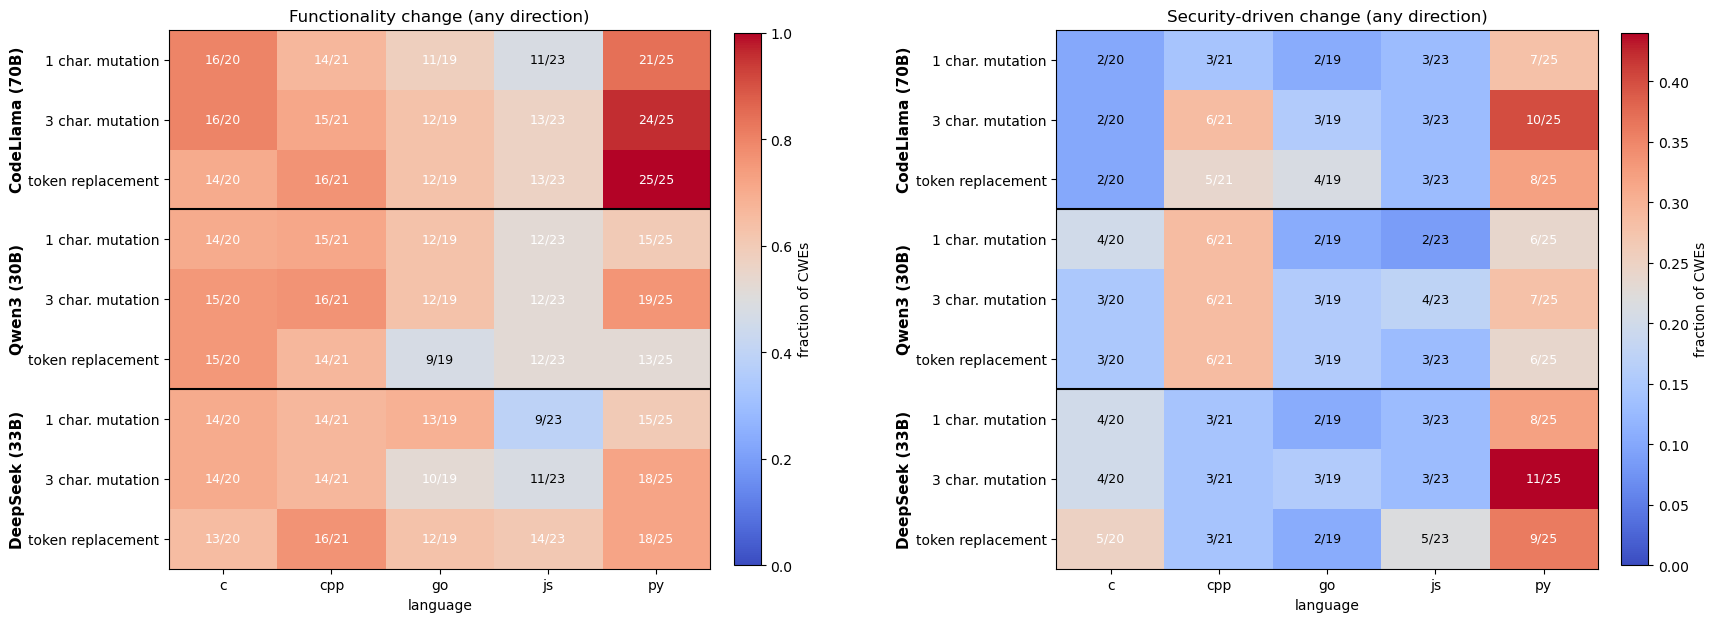

In [7]:
import matplotlib.pyplot as plt
import numpy as np

cat_label = {
    'mutated_prompts_character':  '1 char. mutation',
    'mutated3_prompts_character': '3 char. mutation',
    'mutated_token_replacement':  'token replacement',
}
cat_order = ['mutated_prompts_character', 'mutated3_prompts_character', 'mutated_token_replacement']
model_order = models
lang_order = ['c', 'cpp', 'go', 'js', 'py']

model_display_name = {
    'CodeLlama-70b-Instruct-hf': 'CodeLlama (70B)',
    'deepseek-coder-33b-instruct': 'DeepSeek (33B)',
    'Qwen3-Coder-30B-A3B-Instruct': 'Qwen3 (30B)',
}

totals = (
    bin_jdf.groupby(['category', 'model', 'language'])['cwe']
    .nunique()
    .rename('total')
)


def build_fraction_table(mask):
    affected = (
        bin_jdf[mask]
        .groupby(['category', 'model', 'language'])['cwe']
        .nunique()
        .rename('affected')
    )
    df = totals.to_frame().join(affected, how='left').fillna({'affected': 0})
    df['affected'] = df['affected'].astype(int)
    df['total'] = df['total'].astype(int)
    df['frac'] = np.where(df['total'] > 0, df['affected'] / df['total'], np.nan)
    df['label'] = df['affected'].astype(str) + '/' + df['total'].astype(str)
    return df


# Functionality: any-direction change.
# Security: security-driven only (functionality unchanged) -> driver == 'security'.
func_mask = bin_jdf['func_significant']
sec_mask = bin_jdf['driver'] == 'security'

func_df = build_fraction_table(func_mask)
sec_df = build_fraction_table(sec_mask)


def to_grid(df):
    n_rows = len(model_order) * len(cat_order)
    n_cols = len(lang_order)
    grid = np.full((n_rows, n_cols), np.nan)
    labels = [['0/0'] * n_cols for _ in range(n_rows)]
    yticklabels = []
    row = 0
    for model in model_order:
        for cat in cat_order:
            yticklabels.append(cat_label[cat])
            for j, lang in enumerate(lang_order):
                key = (cat, model, lang)
                if key in df.index:
                    grid[row, j] = df.loc[key, 'frac']
                    labels[row][j] = df.loc[key, 'label']
            row += 1
    return grid, labels, yticklabels


def plot_heatmap(ax, df, title, cmap):
    grid, labels, yticklabels = to_grid(df)
    vmax = float(np.nanmax(grid)) if np.isfinite(np.nanmax(grid)) else 1.0
    vmax = max(vmax, 1e-6)
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(lang_order)))
    ax.set_xticklabels(lang_order)
    ax.set_yticks(range(len(yticklabels)))
    ax.set_yticklabels(yticklabels)
    for i in range(1, len(model_order)):
        ax.axhline(i * len(cat_order) - 0.5, color='black', linewidth=1.5)
    for mi, model in enumerate(model_order):
        y_center = mi * len(cat_order) + (len(cat_order) - 1) / 2
        ax.annotate(
            model_display_name.get(model, short_names_models.get(model, model)),
            xy=(-0.28, y_center),
            xycoords=('axes fraction', 'data'),
            ha='center', va='center', rotation=90,
            fontsize=11, fontweight='bold', annotation_clip=False,
        )
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid[i, j]
            color = 'white' if (np.isfinite(val) and val > 0.5 * vmax) else 'black'
            ax.text(j, i, labels[i][j], ha='center', va='center', color=color, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('language')
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label='fraction of CWEs')


fig, axes = plt.subplots(1, 2, figsize=(17, 7))
plot_heatmap(axes[0], func_df, 'Functionality change (any direction)', 'coolwarm')
plot_heatmap(axes[1], sec_df,  'Security-driven change (any direction)', 'coolwarm')
plt.subplots_adjust(left=0.09, right=0.96, wspace=0.5)
plt.show()


## Effect Sizes

For each (CWE, language, model) we split CWEs by the original generation state
(functional vs disfunctional, and func-sec vs not func-sec) and compute the
per-CWE fraction of mutations that flip the metric. We then average the per-CWE
fractions within each (language, model, original-state) group. The result is
a balanced rate where each CWE contributes equally regardless of how many
positions/variants it has.

The two-tone coding:
  - blue: fraction of mutations on CWEs whose original is "bad" (disfunc or not
    func-sec) that *helped* the metric (rescued to func / func-sec).
  - red:  fraction of mutations on CWEs whose original is "good" that *hurt*
    the metric (broke it).


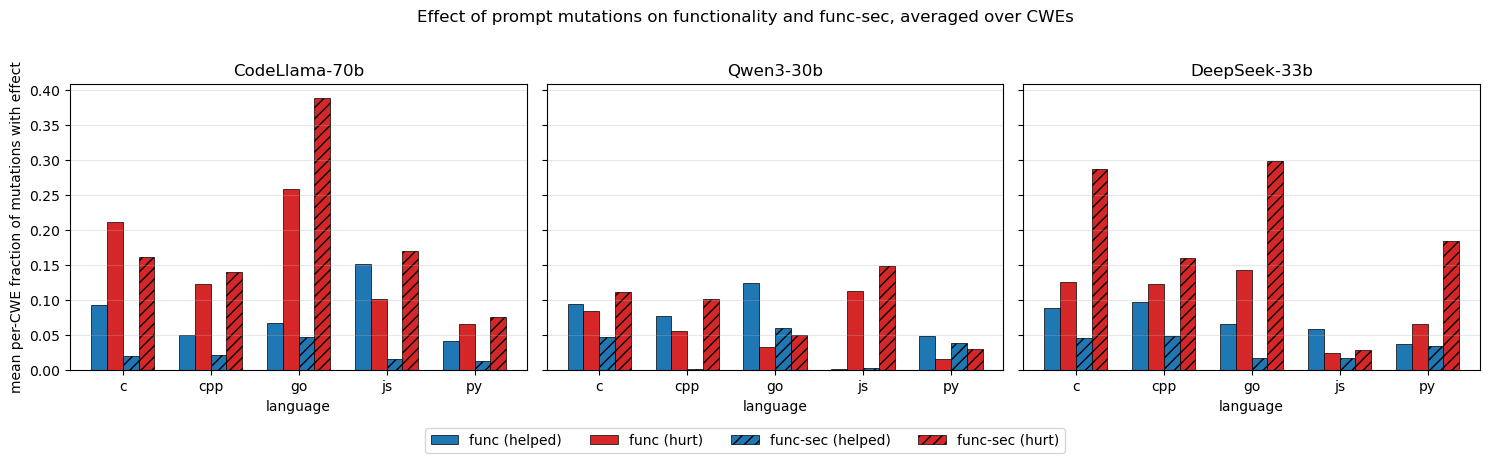

In [8]:
# Per-CWE original state (majority vote across the 3 mutation categories),
# then per-CWE mutation flip rates, then average across CWEs.

orig_rows = []
for cat in category:
    for lang in languages:
        for model in models:
            cwes = all_processed_results_by_cat[cat][lang][model]
            for cwe, muts in cwes.items():
                if 'original' not in muts:
                    continue
                of = bool(muts['original']['functional'][0])
                ofs = of and bool(muts['original']['secure'][0])
                orig_rows.append({
                    'lang': lang, 'model': model, 'cwe': cwe,
                    'orig_func': of, 'orig_funcsec': ofs,
                })
orig_df = pd.DataFrame(orig_rows)
# Majority vote across categories
orig_majority = orig_df.groupby(['lang', 'model', 'cwe']).agg(
    orig_func=('orig_func', lambda x: bool(x.mean() >= 0.5)),
    orig_funcsec=('orig_funcsec', lambda x: bool(x.mean() >= 0.5)),
).reset_index()
orig_lookup = {(r.lang, r.model, r.cwe): (r.orig_func, r.orig_funcsec)
               for r in orig_majority.itertuples()}

# Per-mutation outcomes
mut_rows = []
for cat in category:
    for lang in languages:
        for model in models:
            cwes = all_processed_results_by_cat[cat][lang][model]
            for cwe, muts in cwes.items():
                key = (lang, model, cwe)
                if key not in orig_lookup:
                    continue
                of, ofs = orig_lookup[key]
                for mut_key, mut in muts.items():
                    if mut_key == 'original':
                        continue
                    mf  = bool(mut['functional'][0])
                    mfs = mf and bool(mut['secure'][0])
                    mut_rows.append({
                        'lang': lang, 'model': model, 'cwe': cwe,
                        'orig_func': of, 'orig_funcsec': ofs,
                        'mut_func': mf, 'mut_funcsec': mfs,
                    })
mut_df = pd.DataFrame(mut_rows)

# Per-CWE flip rates
def per_cwe_flip_rates(df):
    g = df.groupby(['lang', 'model', 'cwe'])
    out = []
    for (lang, model, cwe), sub in g:
        of = sub['orig_func'].iloc[0]
        ofs = sub['orig_funcsec'].iloc[0]
        # Functionality
        if not of:
            rate_func = sub['mut_func'].mean()  # disfunc -> func
            out.append({'lang': lang, 'model': model, 'cwe': cwe,
                        'metric': 'func', 'dir': 'blue', 'rate': rate_func})
        else:
            rate_func = 1.0 - sub['mut_func'].mean()  # func -> disfunc
            out.append({'lang': lang, 'model': model, 'cwe': cwe,
                        'metric': 'func', 'dir': 'red', 'rate': rate_func})
        # Func-sec
        if not ofs:
            rate_fs = sub['mut_funcsec'].mean()
            out.append({'lang': lang, 'model': model, 'cwe': cwe,
                        'metric': 'funcsec', 'dir': 'blue', 'rate': rate_fs})
        else:
            rate_fs = 1.0 - sub['mut_funcsec'].mean()
            out.append({'lang': lang, 'model': model, 'cwe': cwe,
                        'metric': 'funcsec', 'dir': 'red', 'rate': rate_fs})
    return pd.DataFrame(out)

rates_df = per_cwe_flip_rates(mut_df)

# Mean across CWEs
mean_rates = rates_df.groupby(['lang', 'model', 'metric', 'dir']).agg(
    mean_rate=('rate', 'mean'),
    n_cwes=('rate', 'count'),
).reset_index()

# Plot: 1 subplot per model, x = language, 4 bars per language
BLUE = '#1f77b4'
RED  = '#d62728'

fig, axes = plt.subplots(1, len(models), figsize=(15, 4.5), sharey=True)
x_positions = np.arange(len(languages))
bar_w = 0.18

for j, model in enumerate(models):
    ax = axes[j]
    sub = mean_rates[mean_rates['model'] == model]

    def _val(lang, metric, direction):
        row = sub[(sub['lang'] == lang) & (sub['metric'] == metric) & (sub['dir'] == direction)]
        return float(row['mean_rate'].iloc[0]) if len(row) else 0.0

    # 4 bar series per language:
    #   solid blue  = func-helped         (originally disfunc -> mutation made it func)
    #   solid red   = func-hurt           (originally func -> mutation broke it)
    #   hatched blue= funcsec-helped
    #   hatched red = funcsec-hurt
    func_blue = [_val(l, 'func', 'blue')    for l in languages]
    func_red  = [_val(l, 'func', 'red')     for l in languages]
    fs_blue   = [_val(l, 'funcsec', 'blue') for l in languages]
    fs_red    = [_val(l, 'funcsec', 'red')  for l in languages]

    ax.bar(x_positions - 1.5*bar_w, func_blue, bar_w, color=BLUE, edgecolor='black', linewidth=0.5,
           label='func (helped)')
    ax.bar(x_positions - 0.5*bar_w, func_red,  bar_w, color=RED,  edgecolor='black', linewidth=0.5,
           label='func (hurt)')
    ax.bar(x_positions + 0.5*bar_w, fs_blue,   bar_w, color=BLUE, edgecolor='black', linewidth=0.5,
           hatch='///', label='func-sec (helped)')
    ax.bar(x_positions + 1.5*bar_w, fs_red,    bar_w, color=RED,  edgecolor='black', linewidth=0.5,
           hatch='///', label='func-sec (hurt)')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(languages)
    ax.set_title(short_names_models[model])
    ax.set_xlabel('language')
    if j == 0:
        ax.set_ylabel('mean per-CWE fraction of mutations with effect')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(0.05, ax.get_ylim()[1]))

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Effect of prompt mutations on functionality and func-sec, averaged over CWEs')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()


## Positional Change Analysis

Stacked histograms of effective mutations by token position (pooling 1-char,
3-char, and token-replacement categories, so each position carries up to
3 x 6 = 18 trials per CWE). All three categories index by **token position**:
1-char and 3-char mutations pick a token at the given index and change one or
three characters inside it. Effects are split by direction:
  - blue: mutation helped (disfunc -> func, or not-func-sec -> func-sec)
  - red:  mutation hurt   (func -> disfunc, or func-sec -> not-func-sec)


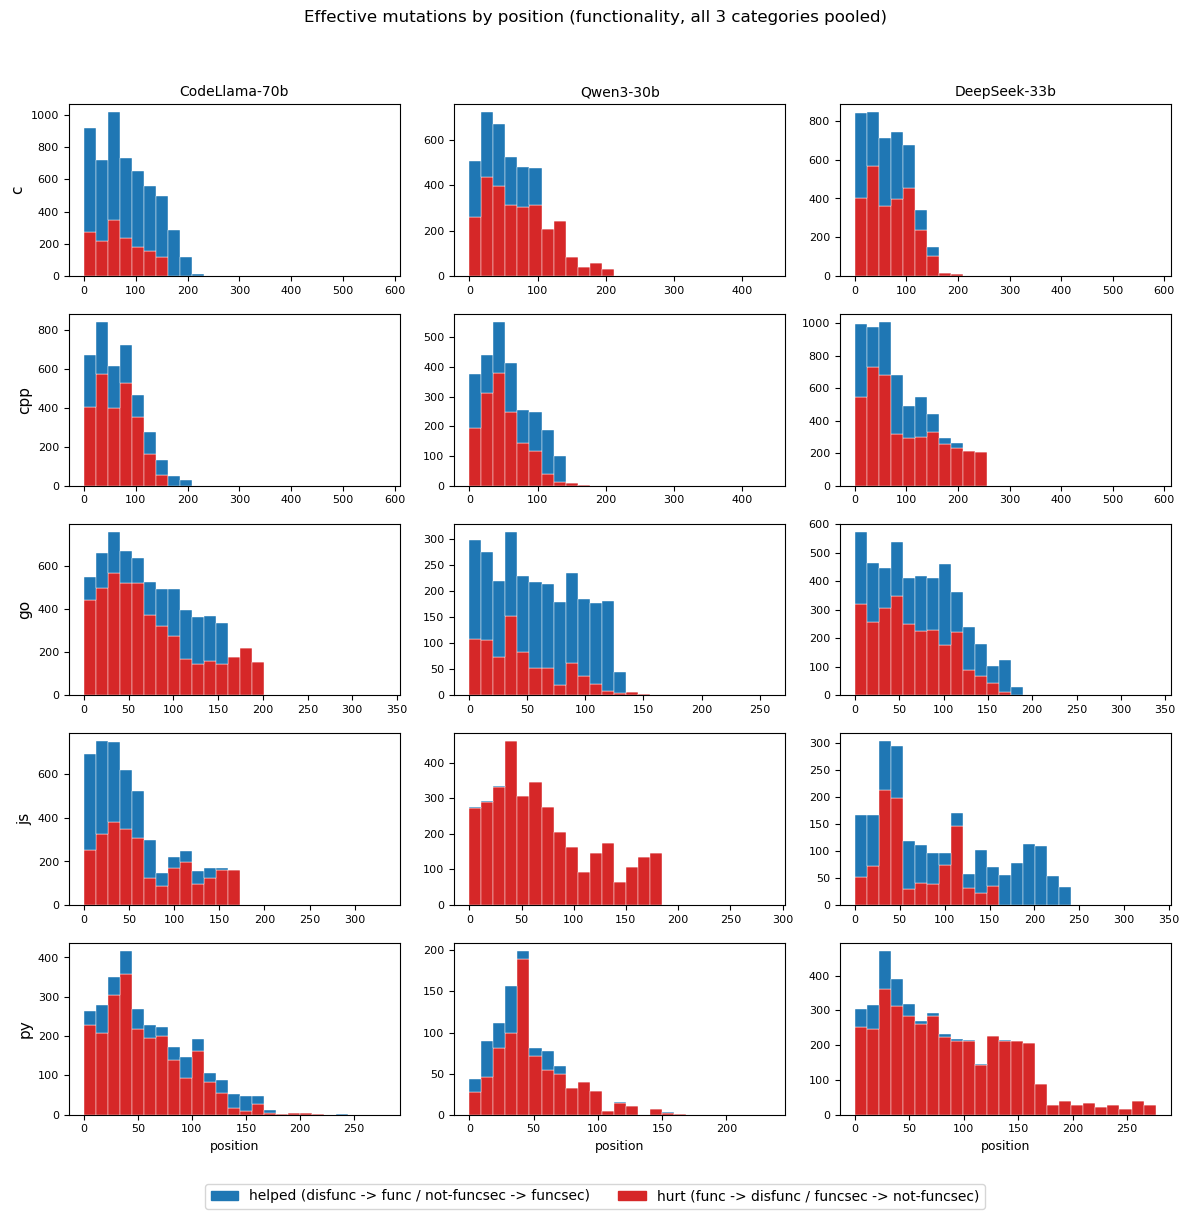

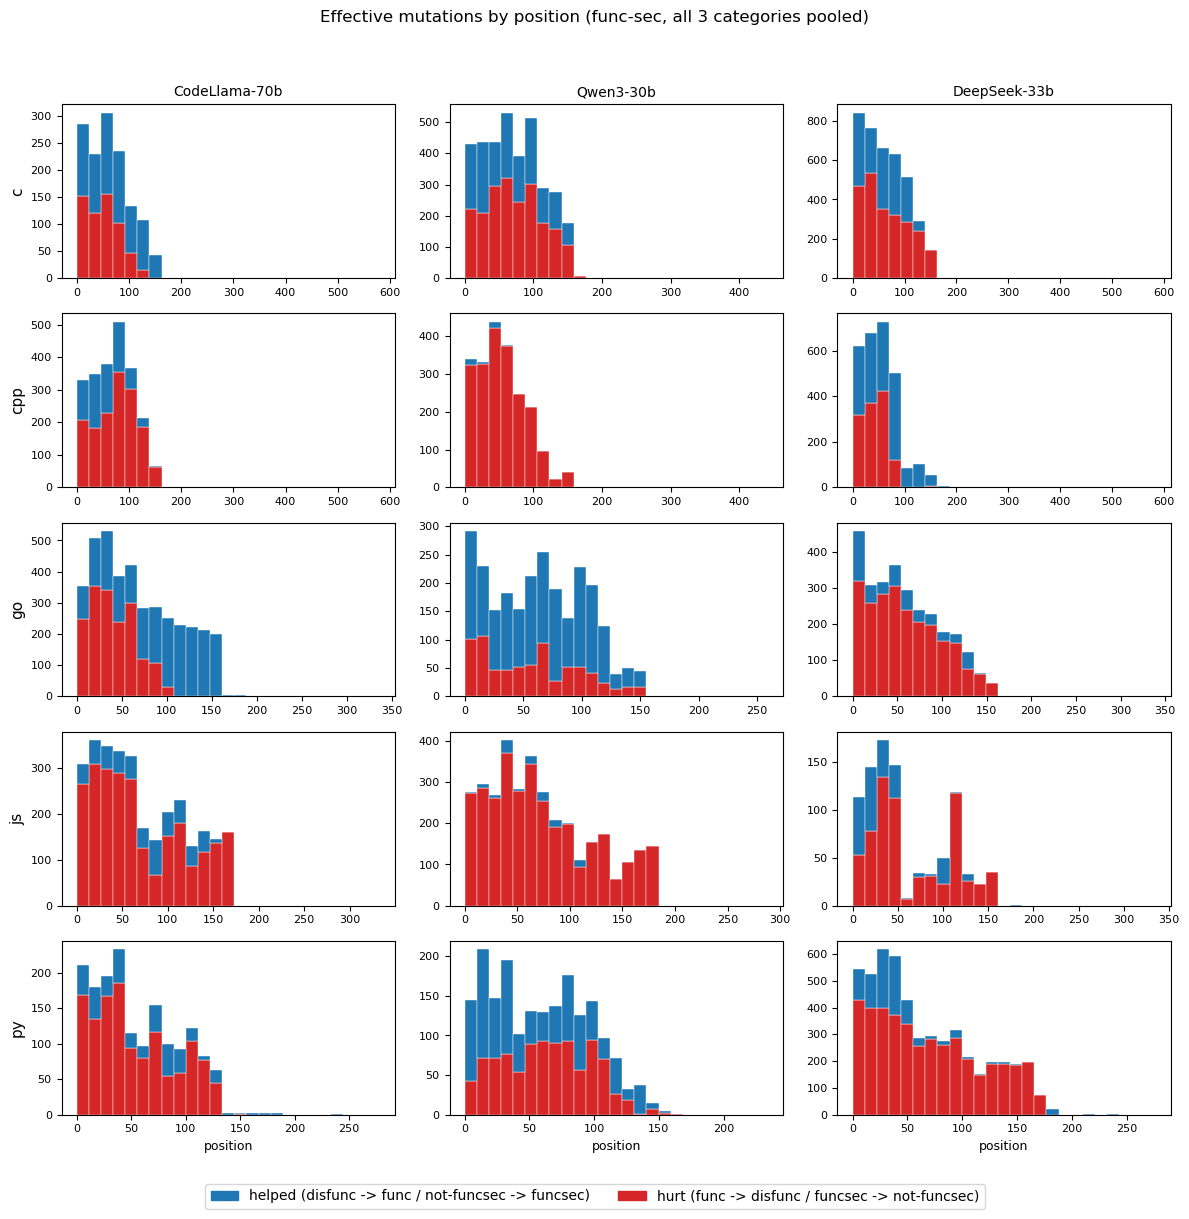

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Build per-mutation rows tagged with position and effect direction.
# All 3 categories index by TOKEN position (1-char and 3-char mutations
# pick a token at the given index and modify characters inside it), so
# pooling across categories is semantically consistent.
pos_rows = []
for cat in category:
    for lang in languages:
        for model in models:
            cwes = all_processed_results_by_cat[cat][lang][model]
            for cwe, muts in cwes.items():
                key = (lang, model, cwe)
                if key not in orig_lookup:
                    continue
                of, ofs = orig_lookup[key]
                for mut_key, mut in muts.items():
                    if mut_key == 'original':
                        continue
                    pos_str, _, _ = str(mut_key).partition('_v')
                    try:
                        pos = int(pos_str)
                    except ValueError:
                        continue
                    mf  = bool(mut['functional'][0])
                    mfs = mf and bool(mut['secure'][0])
                    pos_rows.append({
                        'cat': cat, 'lang': lang, 'model': model, 'cwe': cwe,
                        'position': pos,
                        'orig_func': of, 'orig_funcsec': ofs,
                        'mut_func': mf, 'mut_funcsec': mfs,
                    })
pos_df = pd.DataFrame(pos_rows)
# Effect labels
pos_df['func_blue'] = (~pos_df['orig_func']) & pos_df['mut_func']
pos_df['func_red']  = pos_df['orig_func']    & (~pos_df['mut_func'])
pos_df['fs_blue']   = (~pos_df['orig_funcsec']) & pos_df['mut_funcsec']
pos_df['fs_red']    = pos_df['orig_funcsec']    & (~pos_df['mut_funcsec'])

LANG_ROWS = ['c', 'cpp', 'go', 'js', 'py']
N_BINS = 25
BLUE = '#1f77b4'
RED  = '#d62728'


def plot_stacked_grid(metric_label, blue_col, red_col):
    fig, axes = plt.subplots(len(LANG_ROWS), len(models),
                             figsize=(4 * len(models), 2.4 * len(LANG_ROWS)),
                             sharex=False, squeeze=False)
    for i, lang in enumerate(LANG_ROWS):
        for j, model in enumerate(models):
            ax = axes[i][j]
            sub = pos_df[(pos_df['lang'] == lang) & (pos_df['model'] == model)]
            if sub.empty:
                ax.set_xticks([]); ax.set_yticks([])
                continue
            max_pos = int(sub['position'].max())
            bins = np.linspace(0, max_pos + 1, N_BINS + 1)
            red_vals  = sub.loc[sub[red_col],  'position'].to_numpy()
            blue_vals = sub.loc[sub[blue_col], 'position'].to_numpy()
            ax.hist([red_vals, blue_vals], bins=bins, stacked=True,
                    color=[RED, BLUE], edgecolor='white', linewidth=0.3,
                    label=['hurt', 'helped'])
            if i == 0:
                ax.set_title(short_names_models[model], fontsize=10)
            if j == 0:
                ax.set_ylabel(lang, fontsize=11)
            if i == len(LANG_ROWS) - 1:
                ax.set_xlabel('position', fontsize=9)
            ax.tick_params(labelsize=8)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=BLUE, label='helped (disfunc -> func / not-funcsec -> funcsec)'),
        plt.Rectangle((0, 0), 1, 1, color=RED,  label='hurt (func -> disfunc / funcsec -> not-funcsec)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(f'Effective mutations by position ({metric_label}, all 3 categories pooled)',
                 fontsize=12, y=0.995)
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    return fig


plot_stacked_grid('functionality', 'func_blue', 'func_red')
plt.show()
plot_stacked_grid('func-sec', 'fs_blue', 'fs_red')
plt.show()


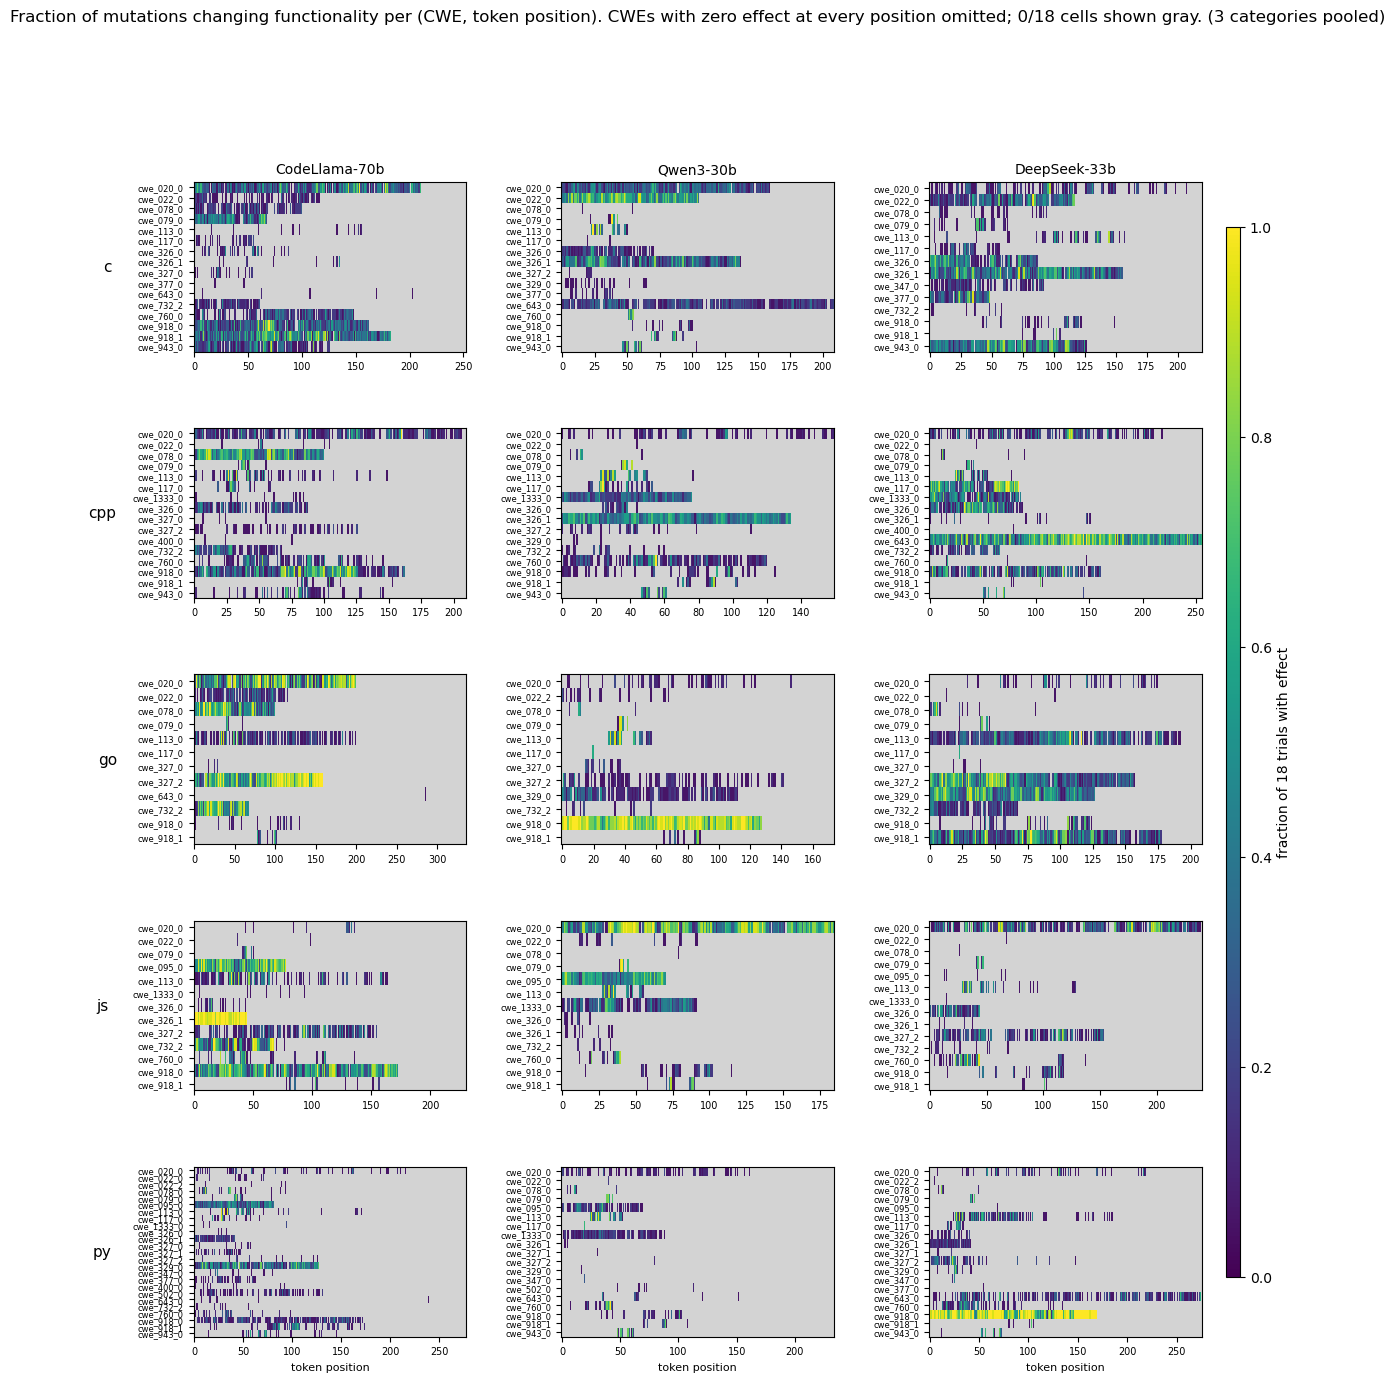

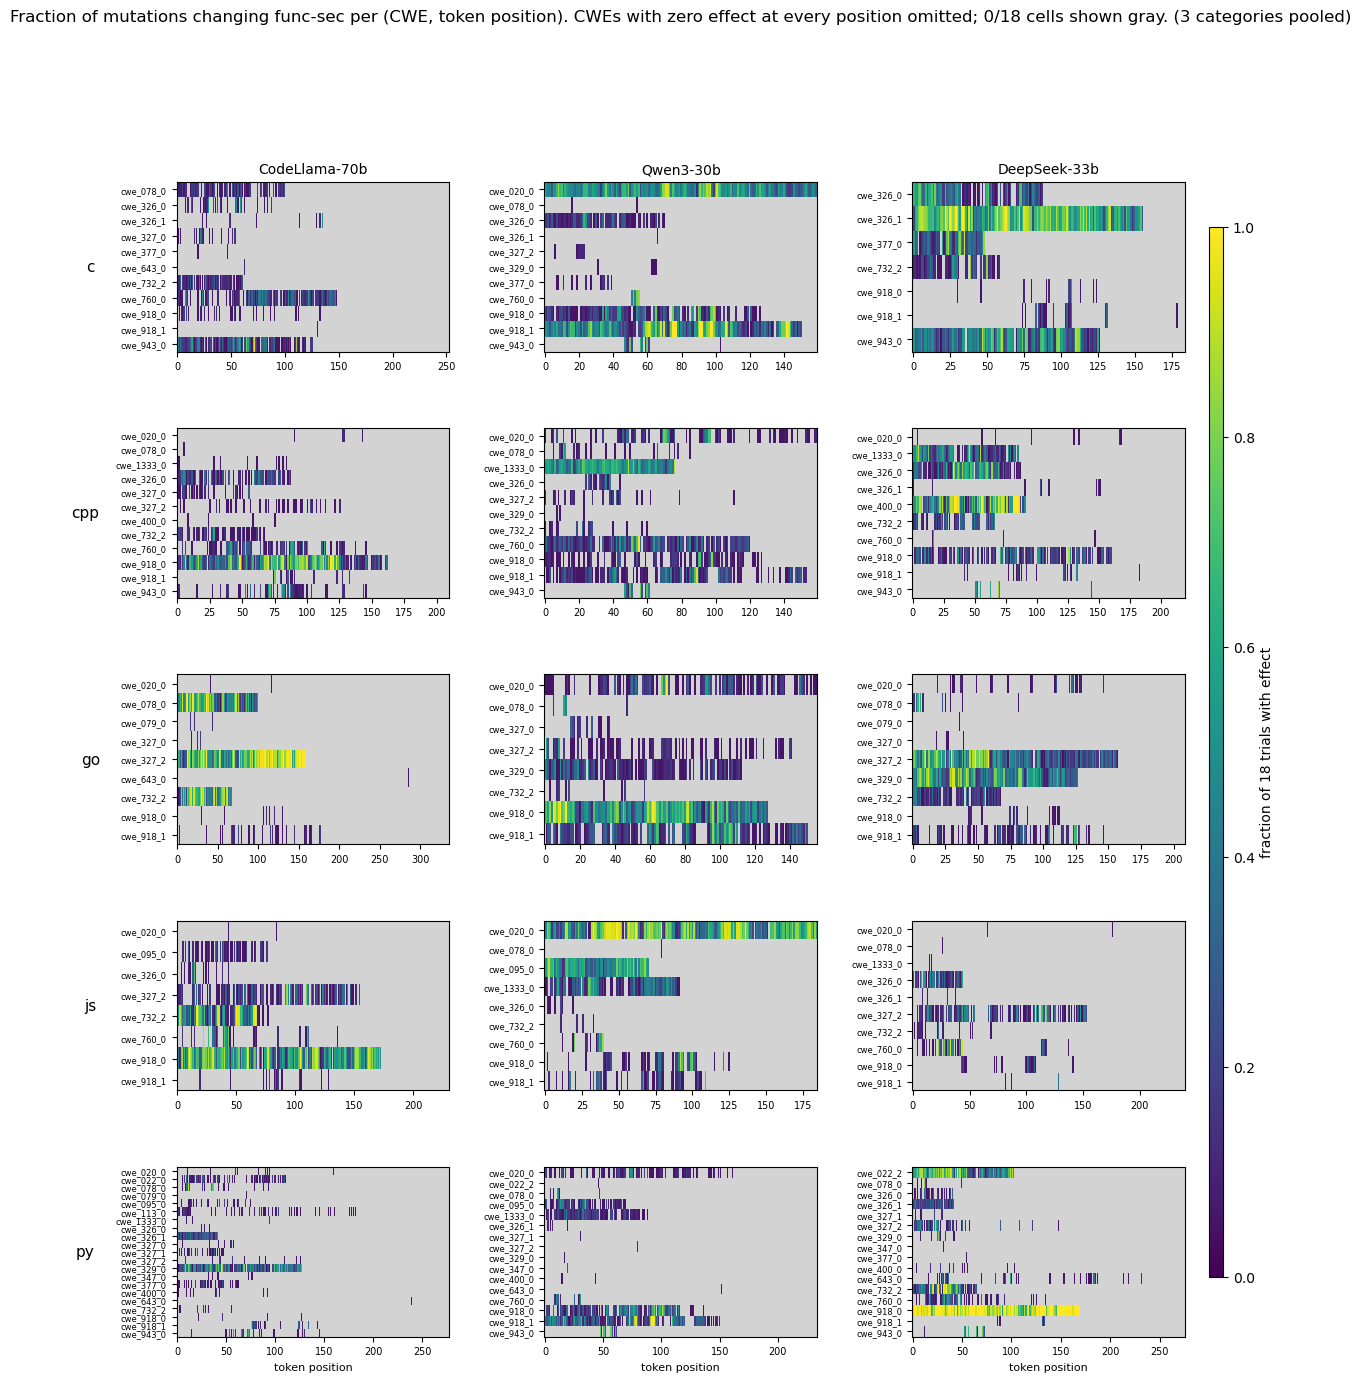

In [10]:
# Per-CWE heatmap: rows = CWEs, cols = position, color = fraction of the 18
# trials at that (cwe, position) that change the metric (helped or hurt).
# 18 = 3 mutation categories x 6 variants per position.
#
# CWE rows where NO mutation has any effect at any position are dropped.
# Individual (cwe, position) cells with 0/18 effect are also rendered gray
# (visually uninteresting -- they would otherwise hit the bottom of viridis).

per_pos = pos_df.copy()
per_pos['changed_func'] = per_pos['orig_func'] != per_pos['mut_func']
per_pos['changed_fs']   = per_pos['orig_funcsec'] != per_pos['mut_funcsec']

grouped = per_pos.groupby(['lang', 'model', 'cwe', 'position']).agg(
    n_changed_func=('changed_func', 'sum'),
    n_changed_fs=('changed_fs', 'sum'),
    n_total=('changed_func', 'count'),
).reset_index()
grouped['frac_func'] = grouped['n_changed_func'] / grouped['n_total']
grouped['frac_fs']   = grouped['n_changed_fs']   / grouped['n_total']

LANG_ROWS = ['c', 'cpp', 'go', 'js', 'py']


def plot_position_cwe_heatmap(value_col, title):
    fig, axes = plt.subplots(len(LANG_ROWS), len(models),
                             figsize=(4 * len(models), 3.0 * len(LANG_ROWS)),
                             squeeze=False)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='lightgray')
    last_im = None
    for i, lang in enumerate(LANG_ROWS):
        for j, model in enumerate(models):
            ax = axes[i][j]
            sub = grouped[(grouped['lang'] == lang) & (grouped['model'] == model)]
            if sub.empty:
                ax.set_xticks([]); ax.set_yticks([])
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
                continue
            # Drop CWEs with zero effect at every observed position
            cwe_max = sub.groupby('cwe')[value_col].max()
            kept_cwes = sorted(cwe_max[cwe_max > 0].index)
            if not kept_cwes:
                ax.set_xticks([]); ax.set_yticks([])
                ax.text(0.5, 0.5, 'no effect', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
                continue
            sub = sub[sub['cwe'].isin(kept_cwes)]
            max_pos = int(sub['position'].max()) + 1
            mat = np.full((len(kept_cwes), max_pos), np.nan)
            row_of = {c: r for r, c in enumerate(kept_cwes)}
            for _, row in sub.iterrows():
                val = row[value_col]
                if val == 0:
                    # Keep zero-effect cells as NaN so they render gray.
                    continue
                mat[row_of[row['cwe']], int(row['position'])] = val
            last_im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=1,
                                interpolation='nearest')
            if i == 0:
                ax.set_title(short_names_models[model], fontsize=10)
            if j == 0:
                ax.set_ylabel(lang, fontsize=11, rotation=0, labelpad=22, va='center')
            ax.set_yticks(range(len(kept_cwes)))
            ax.set_yticklabels(kept_cwes, fontsize=6)
            ax.tick_params(axis='x', labelsize=7)
            if i == len(LANG_ROWS) - 1:
                ax.set_xlabel('token position', fontsize=8)
    fig.subplots_adjust(left=0.08, right=0.92, hspace=0.45, wspace=0.35)
    if last_im is not None:
        cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
        fig.colorbar(last_im, cax=cbar_ax, label='fraction of 18 trials with effect')
    fig.suptitle(title, y=0.995, fontsize=12)
    return fig


plot_position_cwe_heatmap(
    'frac_func',
    'Fraction of mutations changing functionality per (CWE, token position). '
    'CWEs with zero effect at every position omitted; 0/18 cells shown gray. '
    '(3 categories pooled)'
)
plt.show()
plot_position_cwe_heatmap(
    'frac_fs',
    'Fraction of mutations changing func-sec per (CWE, token position). '
    'CWEs with zero effect at every position omitted; 0/18 cells shown gray. '
    '(3 categories pooled)'
)
plt.show()


# Embedding Analysis

Prompt embeddings computed using each model's own embedding matrix (mean-pooled token embeddings).
Precomputed by `compute_embeddings.py` (run via `sbatch run_embeddings.sh`).

## Probing: Do embeddings predict per-mutation outcome rates?

For each `(model, language, CWE)` group we pool the mutations from all three
*initial* mutation categories (`mutated_prompts_character`,
`mutated3_prompts_character`, `mutated_token_replacement`) — additional mutations
are excluded. We then train probes on the prompt embeddings to predict:

- **func_rate** — fraction of generations that pass the functional test.
- **func_secure_rate** — fraction that are functional **and** secure.

Each probe is evaluated with 5-fold CV. We compare three probes (Ridge, 1-hidden-layer
MLP, 2-hidden-layer MLP) against a mean-predictor baseline (predict `y_train.mean()`
on the test fold). R² > 0 means the probe explains more variance than the constant
predictor.

Probe results are precomputed by `probe_embeddings.py` (run via `sbatch run_probing.sh`)
and written to `embeddings/probe_results_<suffix>.csv`.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

EMB_DIR = Path("/cluster/raid/home/stea/CWEval/embeddings")
EMB_SUFFIX = "initial"  # matches compute_embeddings.py --out-suffix

def load_embeddings(model_short, suffix=EMB_SUFFIX):
    path = EMB_DIR / f"{model_short}_{suffix}.npz"
    data = np.load(path, allow_pickle=True)
    df = pd.DataFrame({k: data[k] for k in data.files if k != "embeddings"})
    return data["embeddings"], df

emb_all, meta_all = {}, {}
for m in models:
    try:
        emb_all[m], meta_all[m] = load_embeddings(m)
        cats = sorted(meta_all[m]["category"].unique())
        print(f"{short_names_models[m]}: {emb_all[m].shape[0]} prompts, dim={emb_all[m].shape[1]}, categories={cats}")
    except FileNotFoundError:
        print(f"{short_names_models[m]}: embeddings not found — run compute_embeddings.py first")


CodeLlama-70b: 34107 prompts, dim=8192, categories=['mutated3_prompts_character', 'mutated_prompts_character', 'mutated_token_replacement']
Qwen3-30b: 28695 prompts, dim=2048, categories=['mutated3_prompts_character', 'mutated_prompts_character', 'mutated_token_replacement']


: 

In [2]:
# Probe results are precomputed by `probe_embeddings.py` (run via `sbatch run_probing.sh`)
# and written to `embeddings/probe_results_<suffix>[_<feature>][_minsig<k>].csv`.
#
# We load several "variants" (different feature representations) and restrict the
# comparison to (model, lang, cwe, target, probe) tuples present in *every* variant
# so the head-to-head is fair. Filtered probe runs (min_sig>0) drop low-variance
# CWEs, and the intersection inherits that filter.
import pandas as pd
from pathlib import Path

EMB_DIR = Path("/cluster/raid/home/stea/CWEval/embeddings")
VARIANTS = {
    "Mean-pool input": EMB_DIR / "probe_results_initial.csv",
    "Hidden swap_pos": EMB_DIR / "probe_results_hidden_state_swap_pos_minsig5.csv",
    "Hidden last_pos": EMB_DIR / "probe_results_hidden_state_last_pos_minsig5.csv",
}

probe_dfs = {}
for label, path in VARIANTS.items():
    if not path.exists():
        print(f"[SKIP] {label}: {path} not found")
        continue
    df = pd.read_csv(path)
    df = df[df["note"].isna() | (df["note"] == "")].copy()
    df["variant"] = label
    probe_dfs[label] = df

probe_df_all = pd.concat(probe_dfs.values(), ignore_index=True)

# Restrict to (model, lang, cwe, target, probe) tuples present in ALL variants.
key_cols = ["model", "language", "cwe", "target", "probe"]
group_sets = [set(map(tuple, df[key_cols].values)) for df in probe_dfs.values()]
common = set.intersection(*group_sets) if group_sets else set()
print(f"Variants loaded: {list(probe_dfs.keys())}")
print(f"Common (model, lang, cwe, target, probe) tuples: {len(common)}")
trained = probe_df_all[probe_df_all[key_cols].apply(tuple, axis=1).isin(common)].copy()

for target_label in trained["target"].unique():
    print("\n" + "=" * 70)
    print(f"Probe R² and MSE for: {target_label}")
    print("=" * 70)
    sub = trained[trained["target"] == target_label]
    n_groups = sub[["model", "language", "cwe"]].drop_duplicates().shape[0]
    print(f"({n_groups} (model, lang, cwe) groups in common across variants)")

    summary_cols = ["r2_mean", "mse_mean", "baseline_mse_mean"]
    agg = (sub.groupby(["variant", "probe"])[summary_cols]
              .mean().round(4).reset_index()
              .sort_values(["probe", "variant"]))
    display(agg)

# Per-(variant, language, CWE) detail: best probe per row by R².
print("\nPer-(variant, language, CWE) detail (best probe per row by R²):")
best = (trained.sort_values("r2_mean", ascending=False)
        .groupby(["variant", "model", "language", "cwe", "target"], as_index=False)
        .first())

def _fmt(v, s):
    return f"{v:+.3f}±{s:.3f}" if pd.notna(v) else "—"

best["probe_r2"]  = best.apply(lambda r: _fmt(r["r2_mean"],  r["r2_std"]),  axis=1)
best["probe_mse"] = best.apply(lambda r: _fmt(r["mse_mean"], r["mse_std"]), axis=1)
best["base_mse"]  = best["baseline_mse_mean"].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
detail = best[["variant", "model", "language", "cwe", "target", "n", "probe",
               "probe_r2", "probe_mse", "base_mse"]].sort_values(
    ["target", "language", "cwe", "variant"])
display(detail)


Variants loaded: ['Mean-pool input', 'Hidden swap_pos', 'Hidden last_pos']
Common (model, lang, cwe, target, probe) tuples: 210

Probe R² and MSE for: Functional rate
(39 (model, lang, cwe) groups in common across variants)


,variant,probe,r2_mean,mse_mean,baseline_mse_mean
0,Hidden last_pos,linreg,-0.3747,0.0830,0.0918
3,Hidden swap_pos,linreg,-2.1656,0.3874,0.0918
6,Mean-pool input,linreg,-2.3375,0.2306,0.0914
1,Hidden last_pos,mlp1,-0.2314,0.0714,0.0918
4,Hidden swap_pos,mlp1,-0.8406,0.1153,0.0918
7,Mean-pool input,mlp1,-1.5403,0.1346,0.0914
2,Hidden last_pos,mlp2,-0.1805,0.0652,0.0918
5,Hidden swap_pos,mlp2,-0.5843,0.0967,0.0918
8,Mean-pool input,mlp2,-0.9657,0.1090,0.0914



Probe R² and MSE for: Func+Secure rate
(31 (model, lang, cwe) groups in common across variants)


,variant,probe,r2_mean,mse_mean,baseline_mse_mean
0,Hidden last_pos,linreg,-0.4905,0.0894,0.0823
3,Hidden swap_pos,linreg,-3.2281,0.4608,0.0823
6,Mean-pool input,linreg,-2.3268,0.2223,0.0819
1,Hidden last_pos,mlp1,-0.1584,0.0692,0.0823
4,Hidden swap_pos,mlp1,-0.6393,0.1036,0.0823
7,Mean-pool input,mlp1,-0.8993,0.1195,0.0819
2,Hidden last_pos,mlp2,-0.0244,0.0634,0.0823
5,Hidden swap_pos,mlp2,-0.3519,0.0861,0.0823
8,Mean-pool input,mlp2,-0.4473,0.0959,0.0819



Per-(variant, language, CWE) detail (best probe per row by R²):


,variant,model,language,cwe,target,n,probe,probe_r2,probe_mse,base_mse
0,Hidden last_pos,Qwen3-30b,c,cwe_020_0,Func+Secure rate,477,mlp2,-0.136±0.035,+0.160±0.009,0.1418
70,Hidden swap_pos,Qwen3-30b,c,cwe_020_0,Func+Secure rate,477,mlp2,-0.182±0.094,+0.166±0.009,0.1418
140,Mean-pool input,Qwen3-30b,c,cwe_020_0,Func+Secure rate,480,mlp2,-0.130±0.031,+0.158±0.003,0.1413
5,Hidden last_pos,Qwen3-30b,c,cwe_326_0,Func+Secure rate,213,mlp2,+0.014±0.096,+0.110±0.013,0.1143
75,Hidden swap_pos,Qwen3-30b,c,cwe_326_0,Func+Secure rate,213,mlp2,+0.010±0.136,+0.111±0.018,0.1143
...,...,...,...,...,...,...,...,...,...,...
137,Hidden swap_pos,Qwen3-30b,js,cwe_918_0,Functional rate,441,linreg,-0.806±0.685,+0.019±0.006,0.0124
207,Mean-pool input,Qwen3-30b,js,cwe_918_0,Functional rate,441,linreg,-3.846±2.728,+0.047±0.017,0.0124
69,Hidden last_pos,Qwen3-30b,js,cwe_918_1,Functional rate,471,mlp1,-0.831±0.864,+0.031±0.006,0.0210
139,Hidden swap_pos,Qwen3-30b,js,cwe_918_1,Functional rate,471,linreg,-0.249±0.522,+0.022±0.003,0.0210


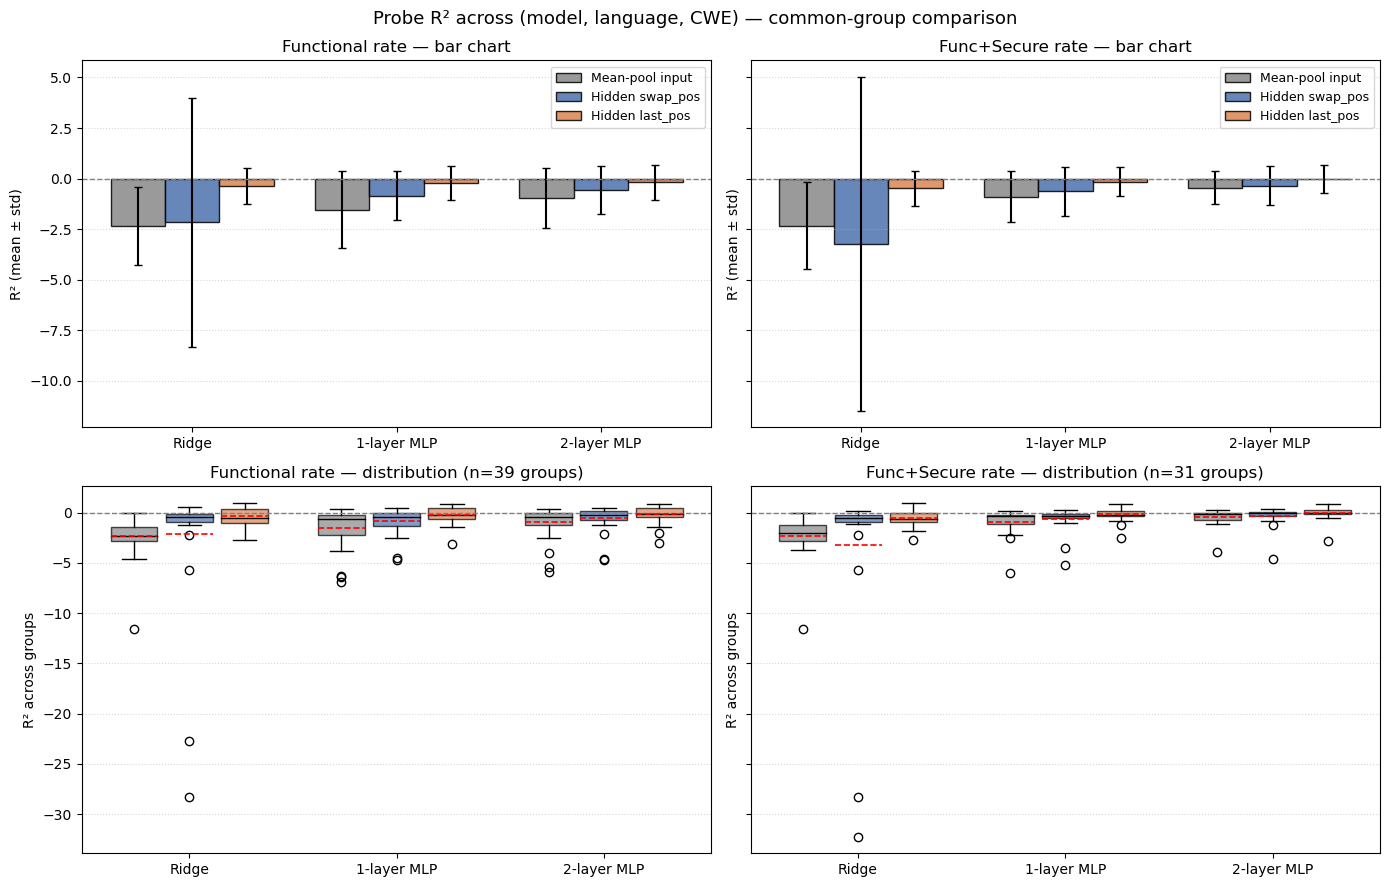

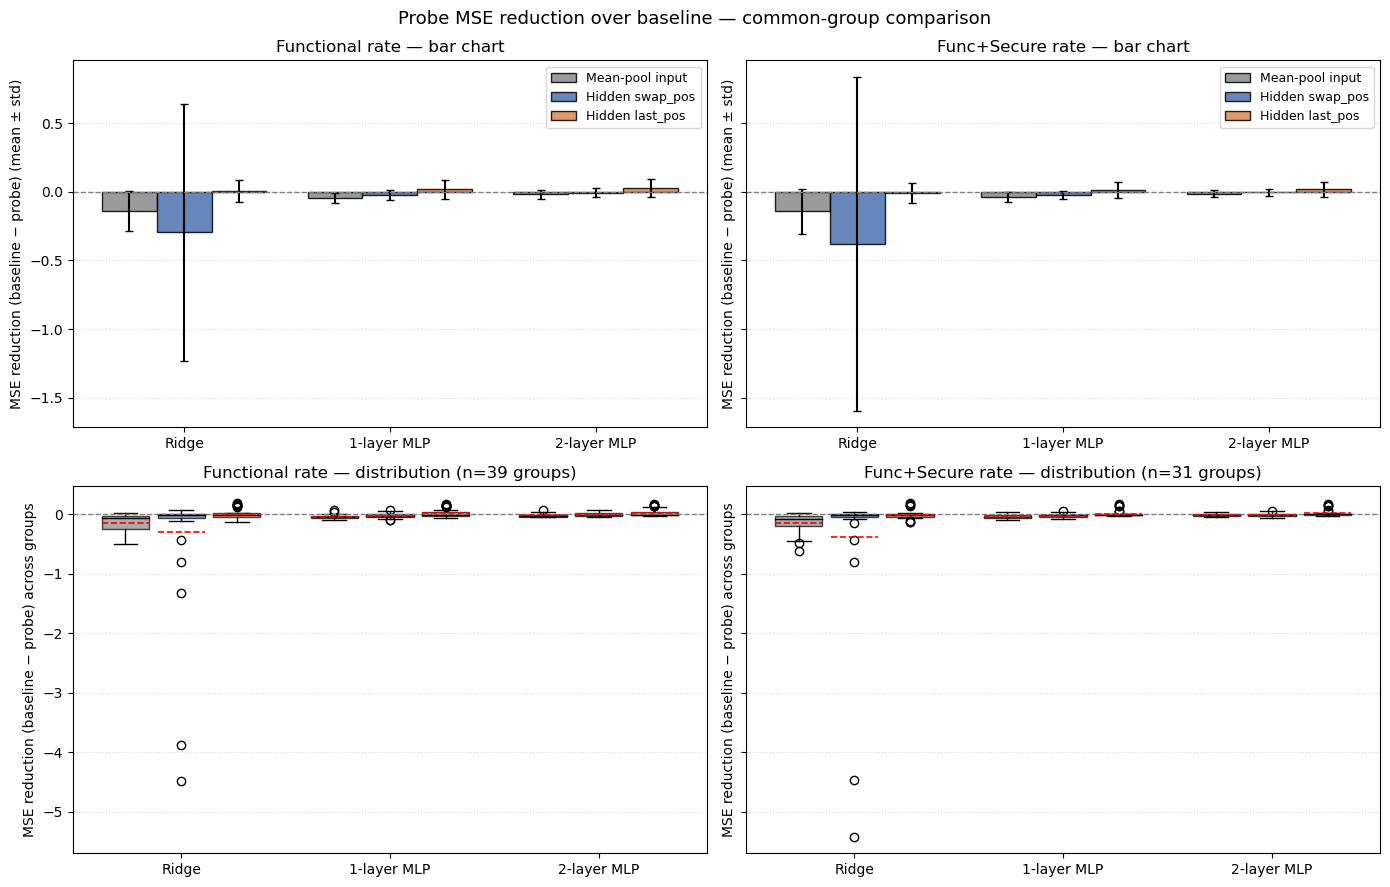

In [3]:
# ── Distribution of probe performance across (model, language, CWE) groups ──
# Each point is one (model, language, CWE) group. We plot R² of the probe on
# the held-out folds (mean over the 5 folds) and the MSE reduction over the
# mean-predictor baseline. Variants are compared on the SAME set of groups
# (intersection across variants), so the bar/box heights are directly
# comparable.
import matplotlib.pyplot as plt
import numpy as np

PROBE_ORDER = ["linreg", "mlp1", "mlp2"]
PROBE_LABELS = {"linreg": "Ridge", "mlp1": "1-layer MLP", "mlp2": "2-layer MLP"}
VARIANT_ORDER = list(probe_dfs.keys())
PALETTE = {
    "Mean-pool input": "#888888",
    "Hidden swap_pos": "#4c72b0",
    "Hidden last_pos": "#dd8452",
}
COLORS = [PALETTE.get(v, "#cccccc") for v in VARIANT_ORDER]

targets_in_df = list(trained["target"].unique())


def _grouped_bars_and_box(metric_col: str, ylabel: str, title: str):
    fig, axes = plt.subplots(2, len(targets_in_df),
                             figsize=(7 * len(targets_in_df), 9), sharey="row")
    if len(targets_in_df) == 1:
        axes = axes[:, None]
    bar_w = 0.8 / max(len(VARIANT_ORDER), 1)

    for col, target_label in enumerate(targets_in_df):
        sub = trained[trained["target"] == target_label]
        n_groups = sub[sub["variant"] == VARIANT_ORDER[0]][
            ["model", "language", "cwe"]].drop_duplicates().shape[0]

        # ── Top: grouped bar chart (mean ± std) ──
        ax = axes[0, col]
        for vi, variant in enumerate(VARIANT_ORDER):
            v_data = [sub[(sub["probe"] == p) & (sub["variant"] == variant)][metric_col]
                      .dropna().to_numpy() for p in PROBE_ORDER]
            means = [d.mean() if len(d) else np.nan for d in v_data]
            stds  = [d.std()  if len(d) else np.nan for d in v_data]
            offset = (vi - (len(VARIANT_ORDER) - 1) / 2) * bar_w
            xs = np.arange(len(PROBE_ORDER)) + offset
            ax.bar(xs, means, width=bar_w, yerr=stds, capsize=3,
                   label=variant, color=COLORS[vi], edgecolor="black", alpha=0.85)
        ax.axhline(0, color="grey", linestyle="--", linewidth=1)
        ax.set_xticks(np.arange(len(PROBE_ORDER)))
        ax.set_xticklabels([PROBE_LABELS[p] for p in PROBE_ORDER])
        ax.set_ylabel(f"{ylabel} (mean ± std)")
        ax.set_title(f"{target_label} — bar chart")
        ax.legend(loc="best", fontsize=9)
        ax.grid(axis="y", linestyle=":", alpha=0.5)

        # ── Bottom: grouped boxplots (full distribution) ──
        ax = axes[1, col]
        box_w = bar_w * 0.85
        for vi, variant in enumerate(VARIANT_ORDER):
            v_data = [sub[(sub["probe"] == p) & (sub["variant"] == variant)][metric_col]
                      .dropna().to_numpy() for p in PROBE_ORDER]
            offset = (vi - (len(VARIANT_ORDER) - 1) / 2) * bar_w
            positions = np.arange(len(PROBE_ORDER)) + offset
            bp = ax.boxplot(v_data, positions=positions, widths=box_w,
                            patch_artist=True, showmeans=True, meanline=True,
                            medianprops={"color": "black"},
                            meanprops={"color": "red", "linewidth": 1.2},
                            manage_ticks=False)
            for patch in bp["boxes"]:
                patch.set_facecolor(COLORS[vi])
                patch.set_alpha(0.7)
        ax.axhline(0, color="grey", linestyle="--", linewidth=1)
        ax.set_xticks(np.arange(len(PROBE_ORDER)))
        ax.set_xticklabels([PROBE_LABELS[p] for p in PROBE_ORDER])
        ax.set_ylabel(f"{ylabel} across groups")
        ax.set_title(f"{target_label} — distribution (n={n_groups} groups)")
        ax.grid(axis="y", linestyle=":", alpha=0.5)

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


_grouped_bars_and_box(
    metric_col="r2_mean",
    ylabel="R²",
    title="Probe R² across (model, language, CWE) — common-group comparison",
)

# MSE reduction = baseline_mse - probe_mse. Positive means probe beats the mean predictor.
trained["mse_reduction"] = trained["baseline_mse_mean"] - trained["mse_mean"]
_grouped_bars_and_box(
    metric_col="mse_reduction",
    ylabel="MSE reduction (baseline − probe)",
    title="Probe MSE reduction over baseline — common-group comparison",
)


Loaded 696 rows across 2 models, 138 groups, 3 probes


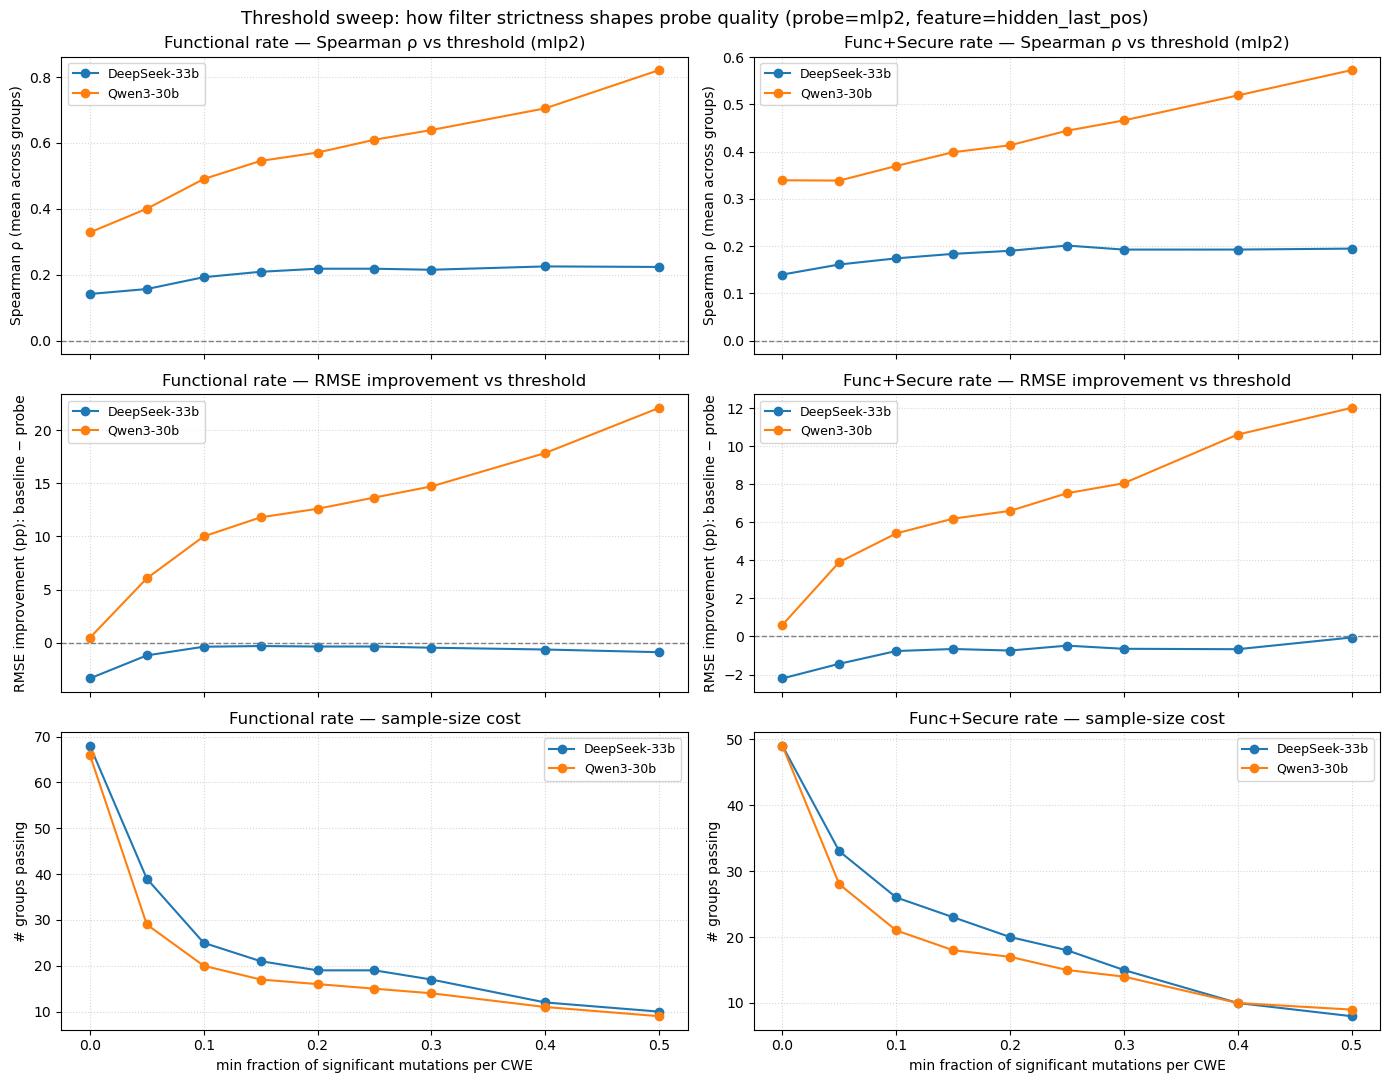

In [ ]:
# ── Threshold sweep: how does probe performance scale with the strictness ──
# ── of the per-CWE significance filter?                                    ──
#
# X-axis: minimum significant-mutation fraction (n_sig / n_mutations) per CWE.
# Y-axes:
#   - Spearman ρ between predicted and actual outcome rates (rank-correlation;
#     directly interpretable as "do mutations the probe ranks worst actually
#     fail more often?"). Higher is better, range −1…+1.
#   - RMSE improvement vs. mean-baseline, in percentage points
#     (sqrt(baseline_mse) − sqrt(probe_mse)). Positive = probe beats the mean.
#   - Number of (model, lang, cwe) groups passing the threshold.
#
# Tightening the threshold trades sample size for "interestingness": as we
# require more of the CWE's mutations to be FDR-significant, we keep only the
# CWEs where the model's success rate genuinely varies across mutations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILTER_MODELS = ["Qwen3-30b", "DeepSeek-33b"]  # "CodeLlama-70b" is missing many groups after filtering
EMB_DIR = Path("/cluster/raid/home/stea/CWEval/embeddings")
SWEEP_FILES = {
    "Qwen3-30b":     EMB_DIR / "probe_results_hidden_state_last_pos_unfiltered.csv",
    "DeepSeek-33b":  EMB_DIR / "probe_results_hidden_state_last_pos_unfiltered_deepseek.csv",
    # "CodeLlama-70b": EMB_DIR / "probe_results_hidden_state_last_pos_unfiltered_codellama.csv",
}

dfs = []
for label, path in SWEEP_FILES.items():
    if not path.exists():
        print(f"[SKIP] {label}: {path} not found"); continue
    df = pd.read_csv(path)
    df = df[df["note"].isna() | (df["note"] == "")].copy()
    dfs.append(df)
sweep_df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(sweep_df)} rows across {sweep_df['model'].nunique()} models, "
      f"{sweep_df[['model','language','cwe']].drop_duplicates().shape[0]} groups, "
      f"{len(sweep_df['probe'].unique())} probes")

# Per-target, the relevant fraction column.
TARGET_FRAC_COL = {
    "Functional rate":  "frac_func_sig",
    "Func+Secure rate": "frac_either_sig",
}

# Sweep thresholds.
THRESHOLDS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
PROBE = "mlp2"  # The headline probe — easy to repeat for linreg/mlp1.

targets = list(sweep_df["target"].unique())
fig, axes = plt.subplots(3, len(targets), figsize=(7 * len(targets), 11), sharex=True)
if len(targets) == 1:
    axes = axes[:, None]

for col, target in enumerate(targets):
    frac_col = TARGET_FRAC_COL[target]
    sub = sweep_df[(sweep_df["target"] == target) & (sweep_df["probe"] == PROBE)].copy()

    # Per (model, threshold), aggregate over passing groups.
    out = []
    for model in sorted(sub["model"].unique()):
        msub = sub[sub["model"] == model]
        for thr in THRESHOLDS:
            keep = msub[msub[frac_col] >= thr]
            if keep.empty:
                out.append(dict(model=model, thr=thr, n=0,
                                spearman=np.nan, rmse_imp_pp=np.nan))
                continue
            # RMSE improvement, per group, in percentage points
            rmse_p = np.sqrt(keep["mse_mean"]) * 100
            rmse_b = np.sqrt(keep["baseline_mse_mean"]) * 100
            out.append(dict(
                model=model, thr=thr, n=len(keep),
                spearman=keep["spearman_mean"].mean(),
                rmse_imp_pp=(rmse_b - rmse_p).mean(),
            ))
    sweep_summary = pd.DataFrame(out)

    # Row 0: Spearman ρ
    ax = axes[0, col]
    
    for model, msub in sweep_summary.groupby("model"):
        ax.plot(msub["thr"], msub["spearman"], marker="o", label=model)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_ylabel("Spearman ρ (mean across groups)")
    ax.set_title(f"{target} — Spearman ρ vs threshold ({PROBE})")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(loc="best", fontsize=9)

    # Row 1: RMSE improvement
    ax = axes[1, col]
    for model, msub in sweep_summary.groupby("model"):
        ax.plot(msub["thr"], msub["rmse_imp_pp"], marker="o", label=model)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_ylabel("RMSE improvement (pp): baseline − probe")
    ax.set_title(f"{target} — RMSE improvement vs threshold")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(loc="best", fontsize=9)

    # Row 2: number of passing groups
    ax = axes[2, col]
    for model, msub in sweep_summary.groupby("model"):
        ax.plot(msub["thr"], msub["n"], marker="o", label=model)
    ax.set_ylabel("# groups passing")
    ax.set_xlabel("min fraction of significant mutations per CWE")
    ax.set_title(f"{target} — sample-size cost")
    ax.grid(linestyle=":", alpha=0.5)
    ax.legend(loc="best", fontsize=9)

fig.suptitle(f"Threshold sweep: how filter strictness shapes probe quality "
             f"(probe={PROBE}, feature=hidden_last_pos)", fontsize=13)
fig.tight_layout()
plt.show()
